In [2]:
import pandas as pd
import numpy as np

In [3]:
# df = pd.read_csv('Maternal Health Risk Data Set.csv')
df2 = pd.read_csv('maternal_health_risk_10000_rows.csv')
df3 = pd.read_csv('maternal_health_synthetic_10000_realistic.csv')

In [4]:
df2

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,24,123,76,5.94,97.7,75,mid risk
1,26,91,57,8.29,98.1,84,low risk
2,15,122,70,6.80,101.9,73,low risk
3,37,112,82,5.87,97.9,89,low risk
4,20,126,75,7.90,97.9,88,mid risk
...,...,...,...,...,...,...,...
9995,18,129,82,7.17,102.5,74,mid risk
9996,46,109,80,7.20,98.2,67,low risk
9997,39,89,74,10.71,97.9,86,high risk
9998,47,125,70,10.26,97.9,79,high risk


In [5]:
df3

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,45,119,84,6.4,98.0,73,mid risk
1,39,103,81,8.2,98.3,64,low risk
2,20,79,80,8.4,100.0,73,high risk
3,28,99,78,9.9,100.8,76,low risk
4,28,124,93,7.1,98.0,83,low risk
...,...,...,...,...,...,...,...
9995,56,133,72,12.8,99.0,69,high risk
9996,18,112,64,8.0,100.2,72,mid risk
9997,27,99,65,7.0,98.7,88,high risk
9998,35,118,83,6.4,98.9,72,low risk


## Merging of  the dataset

In [6]:
df = pd.concat([df2,df3])

In [7]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,24,123,76,5.94,97.7,75,mid risk
1,26,91,57,8.29,98.1,84,low risk
2,15,122,70,6.80,101.9,73,low risk
3,37,112,82,5.87,97.9,89,low risk
4,20,126,75,7.90,97.9,88,mid risk
...,...,...,...,...,...,...,...
9995,56,133,72,12.80,99.0,69,high risk
9996,18,112,64,8.00,100.2,72,mid risk
9997,27,99,65,7.00,98.7,88,high risk
9998,35,118,83,6.40,98.9,72,low risk


## knowing the dataset

In [8]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,24,123,76,5.94,97.7,75,mid risk
1,26,91,57,8.29,98.1,84,low risk
2,15,122,70,6.80,101.9,73,low risk
3,37,112,82,5.87,97.9,89,low risk
4,20,126,75,7.90,97.9,88,mid risk


In [9]:
df.shape

(20000, 7)

In [10]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

In [11]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [12]:
df[df.duplicated()]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel


In [13]:
df = df.drop_duplicates()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          20000 non-null  int64  
 1   SystolicBP   20000 non-null  int64  
 2   DiastolicBP  20000 non-null  int64  
 3   BS           20000 non-null  float64
 4   BodyTemp     20000 non-null  float64
 5   HeartRate    20000 non-null  int64  
 6   RiskLevel    20000 non-null  object 
dtypes: float64(2), int64(4), object(1)
memory usage: 1.2+ MB


In [15]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,29.869850,113.457800,76.600150,8.913735,98.805585,74.333550
std,12.314191,18.724744,14.018003,3.148824,1.239892,8.791169
min,10.000000,70.000000,49.000000,4.000000,96.800000,44.000000
25%,20.000000,99.000000,66.000000,6.500000,98.000000,68.000000
50%,28.000000,114.000000,77.000000,8.045000,98.300000,74.000000
75%,39.000000,127.000000,87.000000,10.400000,99.300000,80.000000
max,70.000000,172.000000,110.000000,20.000000,103.000000,100.000000


In [16]:
df.corr(numeric_only=True)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
Age,1.000000,0.207488,0.196114,0.246552,-0.133830,0.025523
SystolicBP,0.207488,1.000000,0.366275,0.230663,-0.161440,-0.025673
DiastolicBP,0.196114,0.366275,1.000000,0.219794,-0.148445,-0.026818
BS,0.246552,0.230663,0.219794,1.000000,-0.053459,0.072191
BodyTemp,-0.133830,-0.161440,-0.148445,-0.053459,1.000000,0.057181
HeartRate,0.025523,-0.025673,-0.026818,0.072191,0.057181,1.000000


In [17]:
df['RiskLevel']

0        mid risk
1        low risk
2        low risk
3        low risk
4        mid risk
          ...    
9995    high risk
9996     mid risk
9997    high risk
9998     low risk
9999     low risk
Name: RiskLevel, Length: 20000, dtype: object

In [18]:
df['RiskLevel'] = df['RiskLevel'].map(
    {
        'low risk' : 0,
        'mid risk' : 1,
        'high risk' : 2

    }
)

In [19]:
df.corr()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
Age,1.000000,0.207488,0.196114,0.246552,-0.133830,0.025523,0.143331
SystolicBP,0.207488,1.000000,0.366275,0.230663,-0.161440,-0.025673,0.187890
DiastolicBP,0.196114,0.366275,1.000000,0.219794,-0.148445,-0.026818,0.171430
BS,0.246552,0.230663,0.219794,1.000000,-0.053459,0.072191,0.309122
BodyTemp,-0.133830,-0.161440,-0.148445,-0.053459,1.000000,0.057181,0.091603
HeartRate,0.025523,-0.025673,-0.026818,0.072191,0.057181,1.000000,0.084538
RiskLevel,0.143331,0.187890,0.171430,0.309122,0.091603,0.084538,1.000000


In [20]:
import seaborn as sns
import matplotlib as plt

<Axes: >

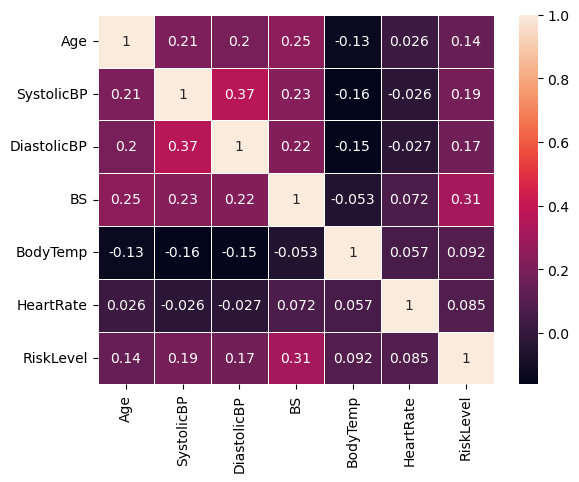

In [21]:
sns.heatmap(df.corr() , annot=True , linewidths=0.5 )


## Data preprocesssing

In [22]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [23]:
df[df.duplicated()]

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel


In [24]:
# handling outliers

<Axes: xlabel='Age'>

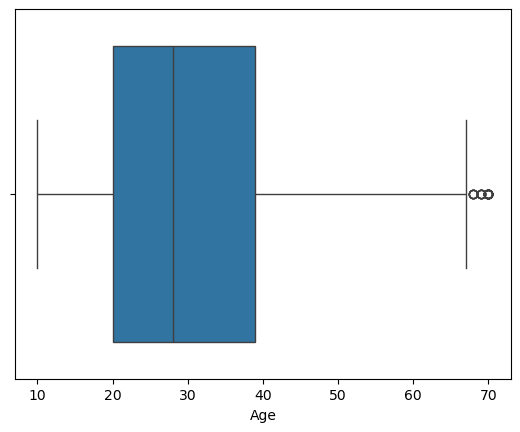

In [25]:
sns.boxplot(data = df , x ='Age')

<Axes: xlabel='SystolicBP'>

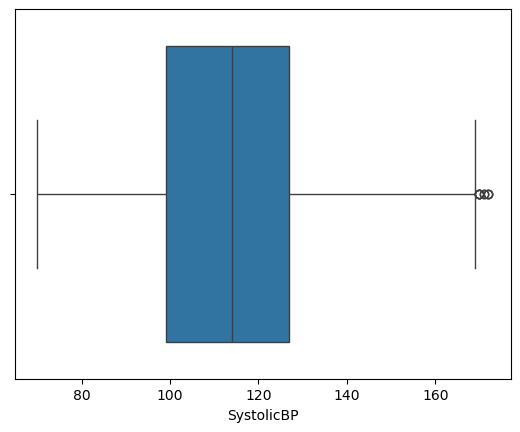

In [26]:
sns.boxplot(data = df , x ='SystolicBP')

<Axes: xlabel='DiastolicBP'>

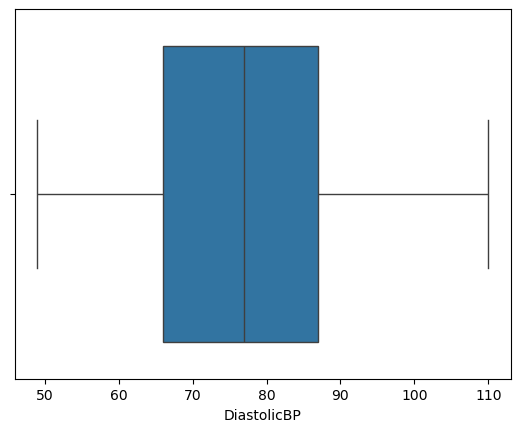

In [27]:
sns.boxplot(data = df , x ='DiastolicBP')

<Axes: xlabel='BS'>

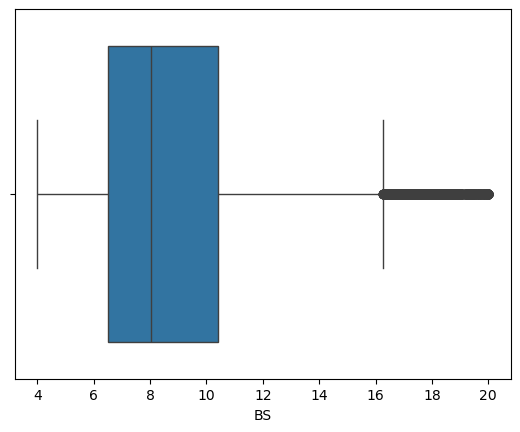

In [28]:
sns.boxplot(data = df , x ='BS')

<Axes: xlabel='BodyTemp'>

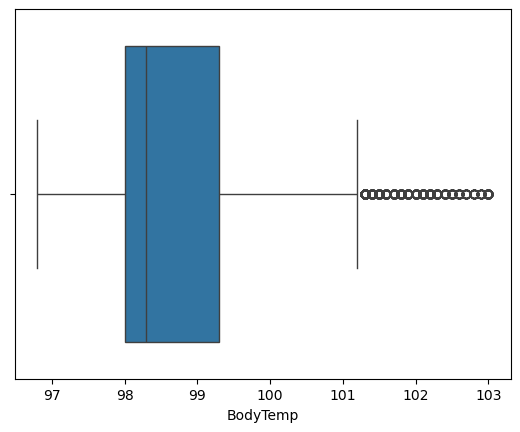

In [29]:
sns.boxplot(data = df , x ='BodyTemp')

<Axes: xlabel='HeartRate'>

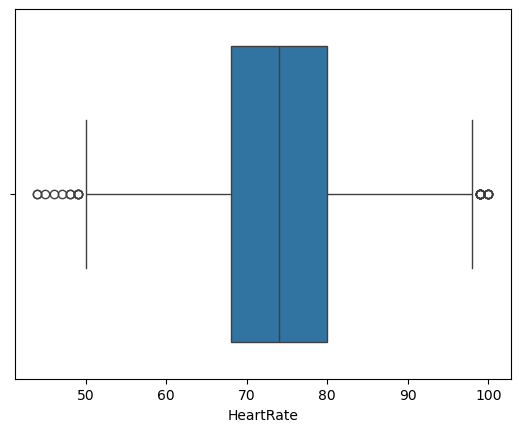

In [30]:
sns.boxplot(data = df , x ='HeartRate')

In [31]:
Q1 = df['SystolicBP'].quantile(0.25)
Q3 = df['SystolicBP'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [33]:
df = df[(df['SystolicBP'] >= lower) & (df['SystolicBP'] <= upper)]

In [34]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,24,123,76,5.94,97.7,75,1
1,26,91,57,8.29,98.1,84,0
2,15,122,70,6.80,101.9,73,0
3,37,112,82,5.87,97.9,89,0
4,20,126,75,7.90,97.9,88,1
...,...,...,...,...,...,...,...
9995,56,133,72,12.80,99.0,69,2
9996,18,112,64,8.00,100.2,72,1
9997,27,99,65,7.00,98.7,88,2
9998,35,118,83,6.40,98.9,72,0


In [36]:
for col in df.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [37]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,24,123,76,5.94,97.7,75,1
1,26,91,57,8.29,98.1,84,0
3,37,112,82,5.87,97.9,89,0
4,20,126,75,7.90,97.9,88,1
6,21,88,59,7.66,98.1,55,0
...,...,...,...,...,...,...,...
9995,56,133,72,12.80,99.0,69,2
9996,18,112,64,8.00,100.2,72,1
9997,27,99,65,7.00,98.7,88,2
9998,35,118,83,6.40,98.9,72,0


In [40]:
import matplotlib.pyplot as plt

<Axes: >

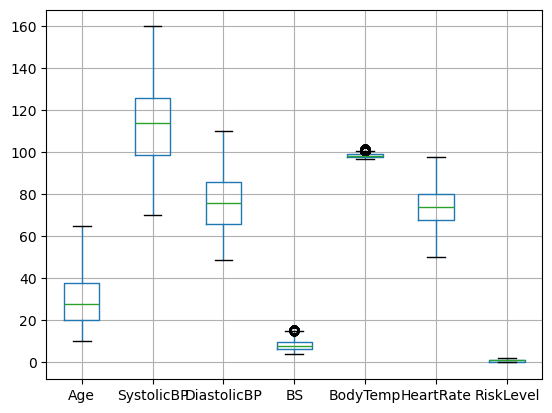

In [57]:
df.boxplot()

## Exploratory Data Analysis